In [1]:
# Load tiny shakespeare text directly from GitHub (fallback method, always works)
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
raw_text = requests.get(url).text

print("Loaded dataset size (characters):", len(raw_text))
print("Preview:", raw_text[:300].replace("\n", "\\n"))



Loaded dataset size (characters): 1115394
Preview: First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us


In [ ]:
# Import required libraries
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Set reproducible random seeds and user-specified hyperparameters
np.random.seed(42)
tf.random.set_seed(42)
SEQ_LENGTH = 25
EMBED_DIM = 128
RNN_UNITS = 128
EPOCHS = 25
BATCH_SIZE = 64
GENERATE_WORDS = 7
VALIDATION_SPLIT = 0.10

In [ ]:
# Preprocess the raw text according to instructions (lowercase, remove punctuation, numbers, extra spaces)
text = raw_text.lower()
text = re.sub(r'[^a-z\s]', ' ', text)  # remove punctuation and special characters and numbers
text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
print("Preprocessed text length (chars):", len(text))
print("Preview:", text[:300])


Preprocessed text length (chars): 1059580
Preview: first citizen before we proceed any further hear me speak all speak speak first citizen you are all resolved rather to die than to famish all resolved resolved first citizen first you know caius marcius is chief enemy to the people all we know t we know t first citizen let us kill him and we ll have


In [ ]:
# Tokenize at word level and build integer word index using the entire vocabulary
tokens = text.split()
tokenizer = Tokenizer(oov_token=None)  # no dedicated OOV token as we use entire vocab
tokenizer.fit_on_texts([text])
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size (including reserved 0):", vocab_size)


Vocabulary size (including reserved 0): 11456


In [ ]:
# Convert entire corpus into integer sequence and create sliding windows of length SEQ_LENGTH+1
encoded = tokenizer.texts_to_sequences([text])[0]
sequences = []
for i in range(0, len(encoded) - (SEQ_LENGTH)):
    seq = encoded[i:i + SEQ_LENGTH + 1]
    sequences.append(seq)
sequences = np.array(sequences)
print("Number of sequences:", sequences.shape[0])


Number of sequences: 208478


In [ ]:
# Split sequences into inputs (first SEQ_LENGTH tokens) and targets (next token)
X = sequences[:, :-1]
y = sequences[:, -1]
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (208478, 25) y shape: (208478,)


In [ ]:
# Split the data into training and validation sets using sklearn
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
print("Train samples:", X_train.shape[0], "Validation samples:", X_val.shape[0])


Train samples: 187630 Validation samples: 20848


In [ ]:
# Define a helper function to build an LSTM model with the specified architecture and hyperparameters
def build_lstm_model(vocab_size, embed_dim=EMBED_DIM, rnn_units=RNN_UNITS, seq_len=SEQ_LENGTH):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=seq_len),
        LSTM(rnn_units),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Build the LSTM model and display its summary
lstm_model = build_lstm_model(vocab_size)
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model while timing training duration and using early stopping for safety
start_time = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2
)
lstm_train_time = time.time() - start_time
print(f"LSTM training time (s): {lstm_train_time:.2f}")


Epoch 1/25
2932/2932 - 31s - 10ms/step - accuracy: 0.0467 - loss: 6.5941 - val_accuracy: 0.0731 - val_loss: 6.3331
Epoch 2/25
2932/2932 - 25s - 9ms/step - accuracy: 0.0863 - loss: 5.9771 - val_accuracy: 0.0925 - val_loss: 6.1397
Epoch 3/25
2932/2932 - 23s - 8ms/step - accuracy: 0.1029 - loss: 5.6330 - val_accuracy: 0.0979 - val_loss: 6.1076
Epoch 4/25
2932/2932 - 23s - 8ms/step - accuracy: 0.1150 - loss: 5.3525 - val_accuracy: 0.1000 - val_loss: 6.1652
Epoch 5/25
2932/2932 - 41s - 14ms/step - accuracy: 0.1260 - loss: 5.1025 - val_accuracy: 0.1014 - val_loss: 6.2439
Epoch 6/25
2932/2932 - 23s - 8ms/step - accuracy: 0.1391 - loss: 4.8679 - val_accuracy: 0.1000 - val_loss: 6.3469
Epoch 7/25
2932/2932 - 23s - 8ms/step - accuracy: 0.1557 - loss: 4.6458 - val_accuracy: 0.0986 - val_loss: 6.4596
Epoch 8/25
2932/2932 - 24s - 8ms/step - accuracy: 0.1759 - loss: 4.4400 - val_accuracy: 0.0967 - val_loss: 6.5811
LSTM training time (s): 212.60


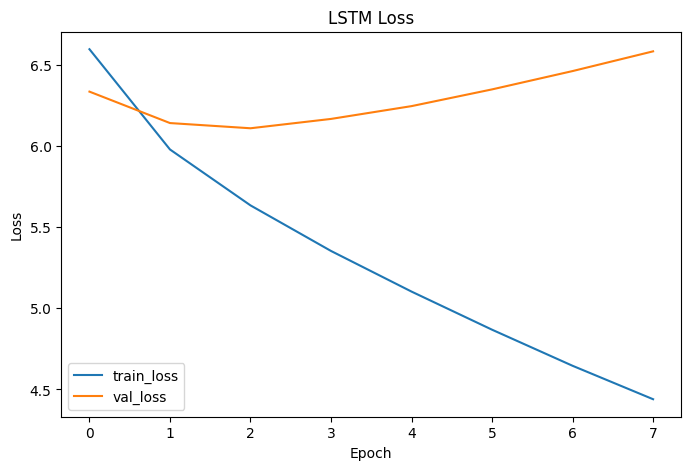

In [ ]:
# Plot the training and validation loss curves for the LSTM model
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='train_loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Compute validation loss and perplexity for the trained LSTM model
val_loss_lstm, _ = lstm_model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)
perplexity_lstm = np.exp(val_loss_lstm)
print(f"LSTM validation loss: {val_loss_lstm:.4f}")
print(f"LSTM perplexity: {perplexity_lstm:.4f}")


LSTM validation loss: 6.1076
LSTM perplexity: 449.2749


In [ ]:
# Define a text generation function that samples from model probability distribution with temperature
def generate_text(model, tokenizer, seed_text, next_words=GENERATE_WORDS, seq_len=SEQ_LENGTH, temperature=1.0):
    result = seed_text.strip()
    for _ in range(next_words):
        tokens = tokenizer.texts_to_sequences([result])[0]
        tokens = pad_sequences([tokens], maxlen=seq_len, padding='pre')
        preds = model.predict(tokens, verbose=0)[0]
        preds = np.asarray(preds).astype('float64')
        preds = np.log(preds + 1e-10) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        next_index = np.random.choice(range(len(preds)), p=preds)
        next_word = tokenizer.index_word.get(next_index, '')
        if next_word == '':
            break
        result += ' ' + next_word
    return result


In [ ]:
# Generate 3 example continuations from the LSTM model for the same seed using different temperatures
seed = "to be or not to"
lstm_examples = []
for temp in [0.7, 1.0, 1.3]:
    gen = generate_text(lstm_model, tokenizer, seed, next_words=GENERATE_WORDS, temperature=temp)
    print(f"Temperature {temp} -> {gen}")
    lstm_examples.append((temp, gen))


Temperature 0.7 -> to be or not to this fashion was thou made a king
Temperature 1.0 -> to be or not to execute this brain and baffled promised thy
Temperature 1.3 -> to be or not to make me look us how then yea


In [ ]:
# Define a helper function to build a GRU model with same architecture as LSTM model
def build_gru_model(vocab_size, embed_dim=EMBED_DIM, rnn_units=RNN_UNITS, seq_len=SEQ_LENGTH):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=seq_len),
        GRU(rnn_units),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Build the GRU model and display its summary
gru_model = build_gru_model(vocab_size)
gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the GRU model while timing training duration and using early stopping for safety
start_time = time.time()
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2
)
gru_train_time = time.time() - start_time
print(f"GRU training time (s): {gru_train_time:.2f}")


Epoch 1/25
2932/2932 - 24s - 8ms/step - accuracy: 0.0610 - loss: 6.4792 - val_accuracy: 0.0881 - val_loss: 6.1712
Epoch 2/25
2932/2932 - 22s - 8ms/step - accuracy: 0.0981 - loss: 5.7694 - val_accuracy: 0.0993 - val_loss: 6.0428
Epoch 3/25
2932/2932 - 22s - 8ms/step - accuracy: 0.1153 - loss: 5.3937 - val_accuracy: 0.1014 - val_loss: 6.0721
Epoch 4/25
2932/2932 - 41s - 14ms/step - accuracy: 0.1301 - loss: 5.0800 - val_accuracy: 0.1006 - val_loss: 6.1470
Epoch 5/25
2932/2932 - 22s - 8ms/step - accuracy: 0.1468 - loss: 4.7927 - val_accuracy: 0.0983 - val_loss: 6.2362
Epoch 6/25
2932/2932 - 22s - 8ms/step - accuracy: 0.1697 - loss: 4.5211 - val_accuracy: 0.0962 - val_loss: 6.3355
Epoch 7/25
2932/2932 - 22s - 8ms/step - accuracy: 0.1961 - loss: 4.2678 - val_accuracy: 0.0938 - val_loss: 6.4453
GRU training time (s): 176.78


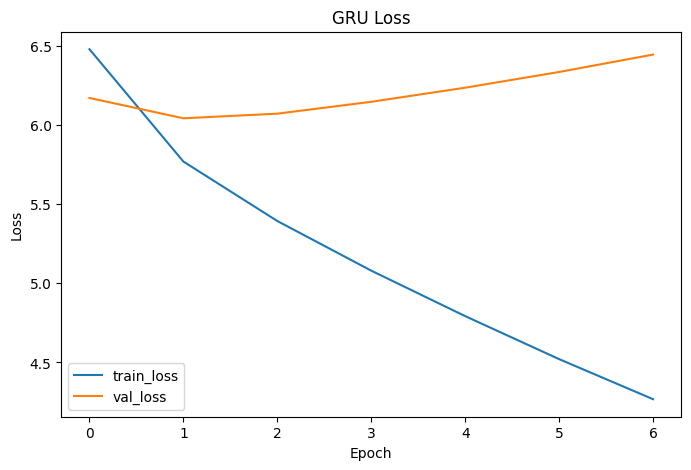

In [ ]:
# Plot the training and validation loss curves for the GRU model
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'], label='train_loss')
plt.plot(history_gru.history['val_loss'], label='val_loss')
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Compute validation loss and perplexity for the trained GRU model
val_loss_gru, _ = gru_model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)
perplexity_gru = np.exp(val_loss_gru)
print(f"GRU validation loss: {val_loss_gru:.4f}")
print(f"GRU perplexity: {perplexity_gru:.4f}")


GRU validation loss: 6.0428
GRU perplexity: 421.0601


In [ ]:
# Generate 3 example continuations from the GRU model for the same seed using different temperatures
gru_examples = []
for temp in [0.7, 1.0, 1.3]:
    gen = generate_text(gru_model, tokenizer, seed, next_words=GENERATE_WORDS, temperature=temp)
    print(f"Temperature {temp} -> {gen}")
    gru_examples.append((temp, gen))


Temperature 0.7 -> to be or not to my name i ll lose the crown
Temperature 1.0 -> to be or not to beat the thinking of the collar monastery
Temperature 1.3 -> to be or not to contend his fair apart ay in grief


In [ ]:
# Collect comparison metrics for both models into a pandas DataFrame
comparison = pd.DataFrame({
    "model": ["LSTM", "GRU"],
    "train_time_sec": [round(lstm_train_time,2), round(gru_train_time,2)],
    "num_parameters": [lstm_model.count_params(), gru_model.count_params()],
    "val_loss": [round(float(val_loss_lstm),4), round(float(val_loss_gru),4)],
    "perplexity": [round(float(perplexity_lstm),4), round(float(perplexity_gru),4)]
})
display(comparison)


,model,train_time_sec,num_parameters,val_loss,perplexity
0,LSTM,212.60,3075776,6.1076,449.2749
1,GRU,176.78,3043264,6.0428,421.0601


In [ ]:
# Add generated example sentences to the comparison DataFrame as additional columns for review
comparison['examples'] = [
    [e for _, e in lstm_examples],
    [e for _, e in gru_examples]
]
display(comparison)


,model,train_time_sec,num_parameters,val_loss,perplexity,examples
0,LSTM,212.60,3075776,6.1076,449.2749,[to be or not to this fashion was thou made a ...
1,GRU,176.78,3043264,6.0428,421.0601,"[to be or not to my name i ll lose the crown, ..."


In [ ]:
# Save both trained models using native Keras format
lstm_model.save("lstm_neural_lm_saved.keras")
gru_model.save("gru_neural_lm_saved.keras")
print("Models saved as .keras files")



Models saved as .keras files


In [ ]:
# Prepare and print a brief conclusion comparing the two models based on observed metrics
conclusion_text = f"""
Conclusion:
- LSTM validation loss: {val_loss_lstm:.4f}, perplexity: {perplexity_lstm:.4f}, train time: {lstm_train_time:.2f}s, params: {lstm_model.count_params()}
- GRU validation loss: {val_loss_gru:.4f}, perplexity: {perplexity_gru:.4f}, train time: {gru_train_time:.2f}s, params: {gru_model.count_params()}

Discuss:
- Use the DataFrame above to argue which model performed better on validation loss / perplexity and which model trained faster.
- Inspect generated examples printed earlier to judge quality of generated text.
"""
print(conclusion_text)



Conclusion:
- LSTM validation loss: 6.1076, perplexity: 449.2749, train time: 212.60s, params: 3075776
- GRU validation loss: 6.0428, perplexity: 421.0601, train time: 176.78s, params: 3043264

Discuss:
- Use the DataFrame above to argue which model performed better on validation loss / perplexity and which model trained faster.
- Inspect generated examples printed earlier to judge quality of generated text.

